# 🌳 VoxCity View Index Analysis

Analyze **Green View Index (GVI)** and **Sky View Index (SVI)** using 3D ray-casting through your voxel city model.

## What are View Indices?

| Index | Description | Use Case |
|-------|-------------|----------|
| **GVI** | Percentage of view occupied by vegetation | Urban greenery assessment |
| **SVI** | Percentage of visible sky | Urban canyon analysis, thermal comfort |

## Key Features

- Ray-casting from observer viewpoint through 3D voxel model
- Configurable azimuth and elevation sampling
- Tree transmissivity modeling (light passes through tree canopy)
- Export results as colored OBJ meshes

## Prerequisites

```python
pip install voxcity
```

INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_complementary_source
INFO | voxcity.voxcity.generator.api | Detected country for ROI center (139.7650, 35.6850): Japan
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=None
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=High Resolution 1m Global Canopy Height Maps | https://gee-community-catalog.org/projects/meta_trees/
INFO | voxcity.voxcity.generator.api | - DEM=DeltaDTM | https://gee-community-catalog.org/projects/delta_dtm/
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
INFO | voxcity.voxcity.generator.grids | Creating Land Use Land Cover grid
 
INFO | voxcity.voxcity.generator.grids | Data source: OpenStreetMap
INFO | vox

Fetching data from Overpass API...
Converting data to GeoJSON format...


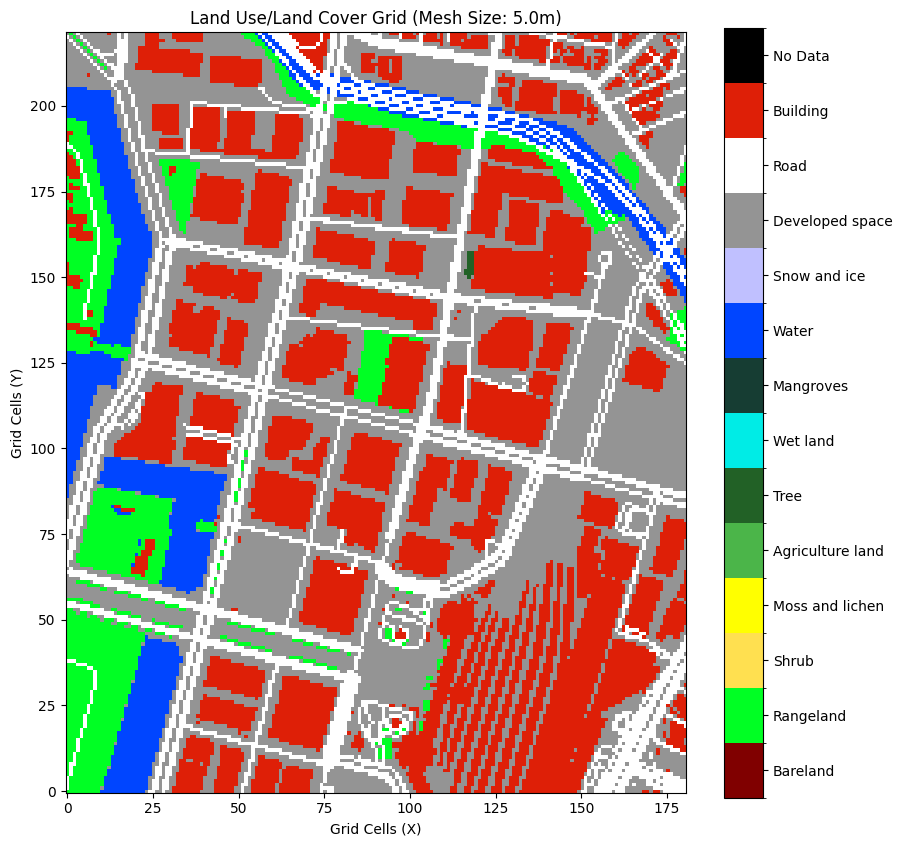

INFO | voxcity.voxcity.generator.grids | Creating Building Height grid
 
INFO | voxcity.voxcity.generator.grids | Base data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | Complementary data source: None
INFO | voxcity.voxcity.geoprocessor.raster.buildings | 240 of the total 351 building footprint from the base data source did not have height data.


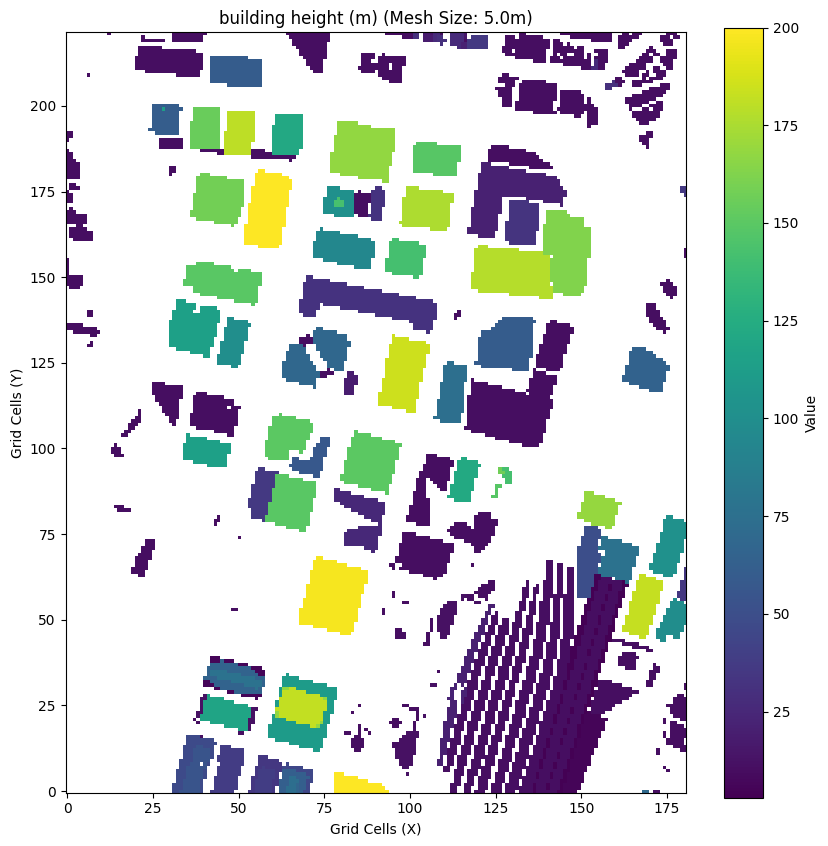

INFO | voxcity.voxcity.generator.grids | Creating Canopy Height grid
 
INFO | voxcity.voxcity.generator.grids | Data source: High Resolution 1m Global Canopy Height Maps


Generating URL ...
Please wait ...
Data downloaded to d:\repository\VoxCity\docs\examples\output\view_demo\canopy_height.tif


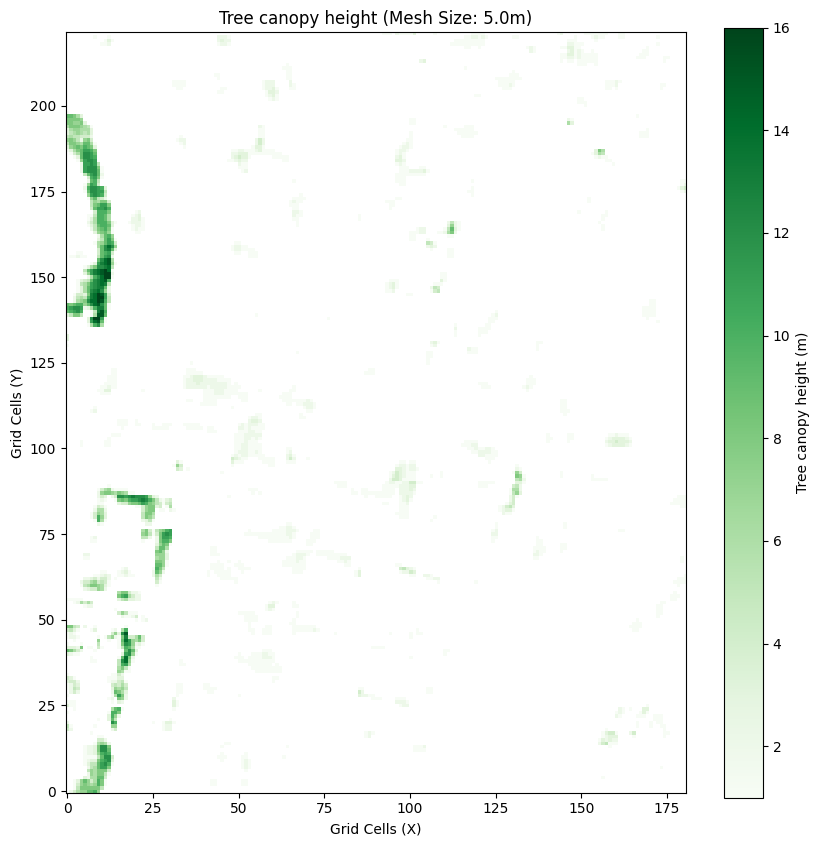

INFO | voxcity.voxcity.generator.grids | Creating Digital Elevation Model (DEM) grid
 
INFO | voxcity.voxcity.generator.grids | Data source: DeltaDTM


Generating URL ...
Please wait ...
Data downloaded to d:\repository\VoxCity\docs\examples\output\view_demo\dem.tif


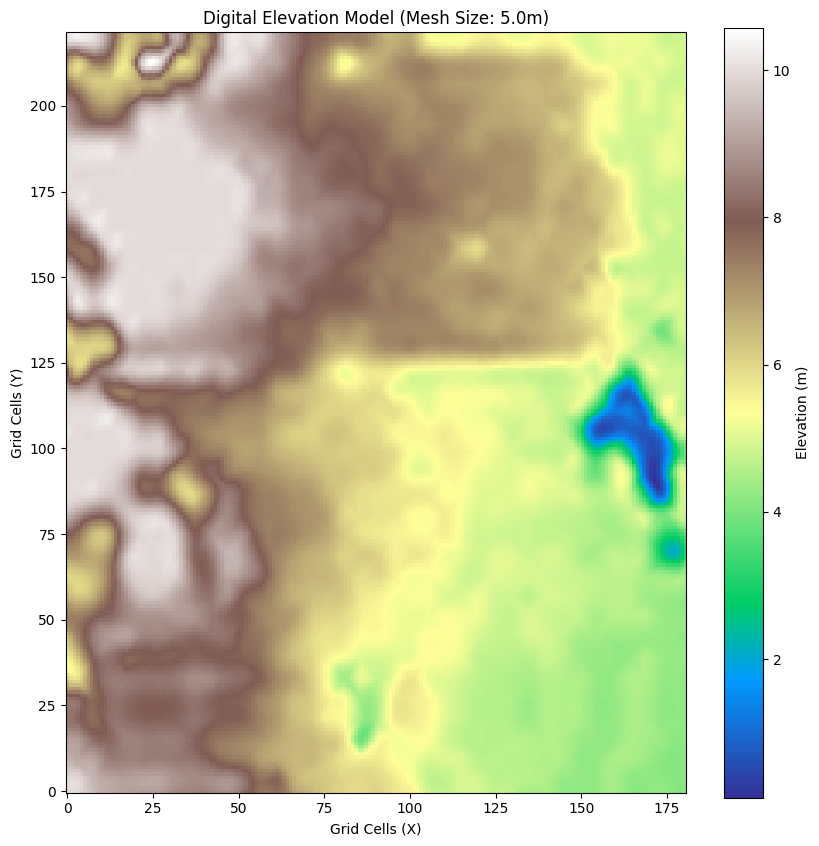

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/view_demo/voxcity.h5


(222, 181, 43)

In [3]:
# %pip install voxcity

from voxcity.generator import get_voxcity
from voxcity.geoprocessor.draw import draw_rectangle_map_cityname
from voxcity.simulator.view import get_view_index

cityname = "Tokyo, Japan"
meshsize = 5

# m, rectangle_vertices = draw_rectangle_map_cityname(cityname, zoom=15)
# m

rectangle_vertices = [
    (139.760, 35.680),  # SW
    (139.760, 35.690),  # NW
    (139.770, 35.690),  # NE
    (139.770, 35.680)   # SE
]

city = get_voxcity(
    rectangle_vertices,
    meshsize=meshsize,
    building_source='OpenStreetMap',
    land_cover_source='OpenStreetMap',
    canopy_height_source='High Resolution 1m Global Canopy Height Maps',
    dem_source='DeltaDTM',
    output_dir='output/view_demo'
)

city.voxels.classes.shape


---
## 🌳 Green View Index (GVI)

Calculate the percentage of visible vegetation from each grid cell.

### Advanced Parameters

| Parameter | Description | Default |
|-----------|-------------|---------|
| `N_azimuth` | Number of azimuth angles | 72 |
| `N_elevation` | Number of elevation angles | 12 |
| `elevation_min_degrees` | Minimum elevation angle | -15° |
| `elevation_max_degrees` | Maximum elevation angle | 30° |
| `ray_sampling` | Sampling method: 'grid' or 'fibonacci' | 'fibonacci' |
| `tree_k` | Extinction coefficient for tree canopy | 0.5 |
| `tree_lad` | Leaf Area Density (LAD) | 1.0 |

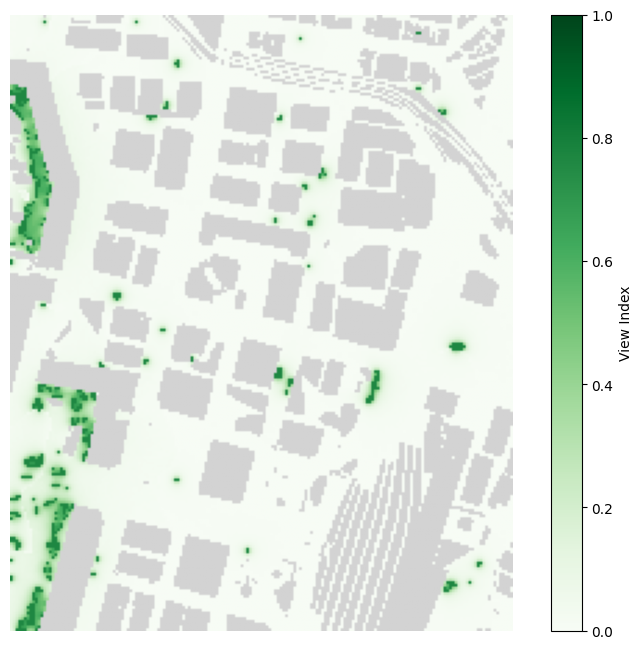

INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/view_demo with the base name "gvi".


(222, 181)

In [2]:
gvi_kwargs = {
    "view_point_height": 1.5,
    "colormap": "Greens",
    "obj_export": True,
    "output_directory": "output/view_demo",
    "output_file_name": "gvi",
    "alpha": 1.0,
    # Ray sampling controls
    "N_azimuth": 72,
    "N_elevation": 12,
    "elevation_min_degrees": -15,
    "elevation_max_degrees": 30,
    "ray_sampling": "fibonacci",  # 'grid' or 'fibonacci'
    # Tree transmittance controls
    "tree_k": 0.5,
    "tree_lad": 1.0,
}

gvi_grid = get_view_index(city, mode='green', **gvi_kwargs)

gvi_grid.shape


---
## 🌤️ Sky View Index (SVI)

Calculate the percentage of visible sky from each grid cell.

For SVI, the elevation range is typically from horizon (0°) to zenith (90°).

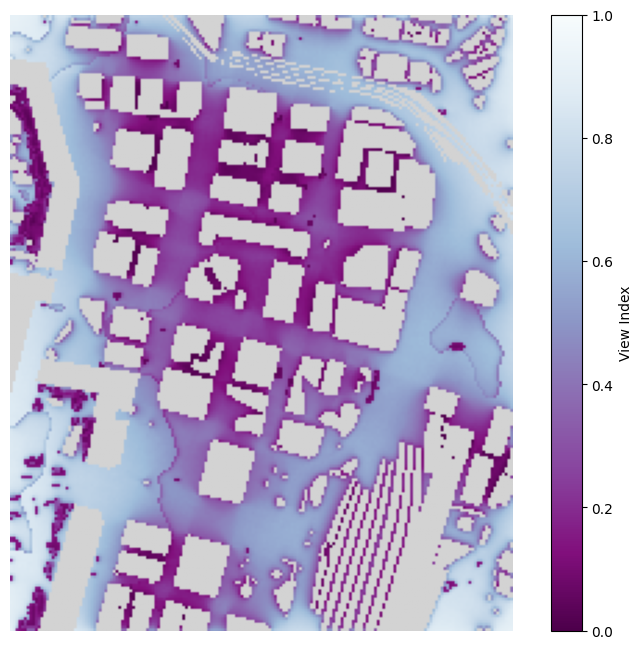

INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/view_demo with the base name "svi".


(222, 181)

In [4]:
svi_kwargs = gvi_kwargs.copy()
svi_kwargs["colormap"] = "BuPu_r"
svi_kwargs["output_file_name"] = "svi"
svi_kwargs["elevation_min_degrees"] = 0
svi_kwargs["elevation_max_degrees"] = 90

svi_grid = get_view_index(city, mode='sky', **svi_kwargs)

svi_grid.shape


---
## 📊 Interpreting Results

- **GVI values** range from 0 to 1 (0% to 100% vegetation visibility)
- **SVI values** range from 0 to 1 (0% to 100% sky visibility)
- Results are exported as colored OBJ files for visualization in Blender/Rhino
- Higher `N_azimuth` and `N_elevation` values give more accurate but slower results

## Next Steps

- `demo_solar.ipynb` - Solar irradiance simulation
- `demo_landmark.ipynb` - Landmark visibility analysis
- `demo_3d_visualization.ipynb` - Advanced 3D visualization